# Regressão Simbólica — Redescoberta de Leis Físicas

## O que é regressão simbólica

Na regressão clássica você define a forma da equação antes de ajustá-la — por exemplo, assume que a relação é linear e encontra os coeficientes `a` e `b` de `y = ax + b`. A forma funcional é uma escolha sua, não do algoritmo.

A regressão simbólica não parte de nenhuma suposição sobre a forma. Dados os valores de entrada e saída, o algoritmo busca simultaneamente a estrutura matemática da equação e seus coeficientes. O resultado é uma expressão legível — como `y = 3.14·x²` — em vez de uma caixa preta.

## Como o PySR funciona

O PySR usa um algoritmo genético para evoluir uma população de expressões matemáticas. Cada expressão é representada como uma árvore de operações — nós internos são operadores (`+`, `×`, `sin`) e folhas são variáveis ou constantes. O algoritmo avalia cada expressão pelo erro nos dados, seleciona as melhores, e as combina ou modifica para gerar novas expressões. Após muitas gerações, as equações convergem para formas que descrevem bem os dados.

## O problema da complexidade — fronteira de Pareto

Uma equação com muitos termos pode ajustar qualquer conjunto de dados perfeitamente, mas não revela nenhuma lei física — é overfitting simbólico. O PySR equilibra dois objetivos simultaneamente: minimizar o erro de ajuste e minimizar a complexidade da expressão. As equações que não podem melhorar em um objetivo sem piorar no outro formam a **fronteira de Pareto**. O algoritmo retorna essa fronteira completa, e cabe ao pesquisador escolher o ponto que faz mais sentido físico.


## Problema 1 — Queda livre

### Objetivo
Redescobrir a equação da posição em função do tempo para um objeto em queda livre:

$$y(t) = y_0 - \frac{1}{2}g t^2$$

### Escolha dos operadores
Como a equação esperada é um polinômio de grau 2 em `t`, não há justificativa física para incluir funções como `sin`, `exp` ou `log`. Os operadores foram limitados a `+`, `-`, `*` e `square` — o mínimo necessário para representar a lei correta. Essa restrição também reduz o espaço de busca e o tempo de execução, o que é relevante dado o hardware disponível.

### Parâmetros do modelo
O número de iterações foi mantido baixo (40) pois a equação é simples e o algoritmo converge rapidamente. O `maxsize=15` é mais que suficiente para uma expressão com poucos termos. Os demais parâmetros foram mantidos no padrão do PySR.

### Limitação: a constante gravitacional
Os dados foram gerados inteiramente para a Terra, onde `g = 9.81 m/s²` é constante. Sem variação nesse valor, o modelo não consegue identificar `g` como grandeza física independente — ele absorve o valor numérico diretamente no coeficiente encontrado. Para isolar `g` seria necessário dados de múltiplos corpos celestes com gravidades diferentes, como Marte, Lua e Júpiter.

### Outras limitações
- Apenas uma altura inicial foi simulada, então `y₀` aparece como constante fixa
- Não foi definido um limite para a queda — o objeto atravessa o chão
- É uma simplificação do problema real, mas serve como primeira validação do método

### Resultado esperado
O modelo deve encontrar algo próximo de `y = 100 - 4.9 * t²`, onde 4.9 ≈ g/2.

In [15]:
%pip uninstall pysr juliacall juliapkg julia -y'
%pip install pysr==0.19.3
%python -c "import pysr; pysr.install()"

Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\projeto\symbolic_regression_physics\.venv\Scripts\python.exe -m pip uninstall [options] <package> ...
  c:\projeto\symbolic_regression_physics\.venv\Scripts\python.exe -m pip uninstall [options] -r <requirements file> ...

no such option: -'


  Attempting uninstall: juliacall
    Found existing installation: juliacall 0.9.26
    Uninstalling juliacall-0.9.26:
      Successfully uninstalled juliacall-0.9.26
  Attempting uninstall: pysr
    Found existing installation: pysr 1.5.10
    Uninstalling pysr-1.5.10:
      Successfully uninstalled pysr-1.5.10
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
UsageError: Line magic function `%python` not found (But cell magic `%%python` exists, did you mean that instead?).


In [1]:
from pysr import PySRRegressor
print("ok")

[juliapkg] Found dependencies: c:\projeto\symbolic_regression_physics\.venv\lib\site-packages\pysr\juliapkg.json
[juliapkg] Found dependencies: c:\projeto\symbolic_regression_physics\.venv\lib\site-packages\juliapkg\juliapkg.json
[juliapkg] Found dependencies: c:\projeto\symbolic_regression_physics\.venv\lib\site-packages\juliacall\juliapkg.json
[juliapkg] Locating Julia ~1.6.7, ~1.7, ~1.8, ~1.9, =1.10.0, ~1.10.3
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.10.11 to c:\projeto\symbolic_regression_physics\.venv\julia_env\pyjuliapkg\install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia from https://julialang-s3.julialang.org

In [13]:
import numpy as np
from pysr import PySRRegressor

data = np.loadtxt("../data/raw/dados_queda_livre.csv", delimiter=",", skiprows=1)
t = data[:, 0]
y = data[:, 1]




model = PySRRegressor(
    model_selection="best", # Foca na precisão em vez de apenas simplicidade
    niterations=100,
    
    #operadores
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square"],
    
    temp_equation_file=True,
    delete_tempfiles=True,
    output_directory=None, # Tenta não criar a pasta 'outputs'
    
    # para o ruido, ainda falta melhorar
    # weights=1.0 / (np.full_like(y, 0.1)**2), 
    
    #complexidade e parsimônia
    maxsize=20, # Limita o tamanho da equação para não "alucinar" no ruído
    #parsimony=0.001,
    
    variable_names=["t", "G"]
)

model.fit(X, y)

print("\nEquação com relação de variáveis:")
print(model.get_best().equation)

c:\projeto\symbolic_regression_physics\.venv\Lib\site-packages\pysr\julia_import.py:13: UserWarning: juliacall module already imported. Make sure that you have set the environment variable `PYTHON_JULIACALL_HANDLE_SIGNALS=yes` to avoid segfaults. Also note that PySR will not be able to configure `PYTHON_JULIACALL_THREADS` or `PYTHON_JULIACALL_OPTLEVEL` for you.
  warnings.warn(


ImportError: cannot import name 'AnyValue' from 'juliacall' (c:\projeto\symbolic_regression_physics\.venv\Lib\site-packages\juliacall\__init__.py)

## Problema 2 — Oscilador harmônico

### Objetivo
Redescobrir a equação da posição em função do tempo para uma massa presa a uma mola:

$$x(t) = A \cos(\omega t)$$

onde $A$ é a amplitude e $\omega = \sqrt{k/m}$ é a frequência angular natural do sistema.

### Escolha dos operadores
A solução do oscilador harmônico é inerentemente oscilatória — diferente da queda livre, aqui `cos` é fisicamente necessário. O operador `square` foi mantido pois pode aparecer em representações equivalentes. Divisão foi incluída pois $\omega$ pode emergir como razão entre parâmetros. Operadores como `exp`, `log` e `sin` foram excluídos por não terem justificativa física para esse sistema.

### Parâmetros do modelo
O número de iterações foi aumentado para 100 em relação à queda livre — a equação é mais complexa e o espaço de busca maior. O `maxsize=20` permite expressões com mais termos, necessário para capturar o produto $A \cdot \cos(\omega t)$.

### Limitação: amplitude e frequência como constantes
Assim como `g` na queda livre, $A$ e $\omega$ não aparecem como variáveis independentes — os dados foram gerados com valores fixos de `k`, `m` e condição inicial. O modelo vai absorver esses valores como coeficientes numéricos. Para descobrir $\omega = \sqrt{k/m}$ como relação física seria necessário variar `k` e `m` entre experimentos e passar essas grandezas como colunas do dataset.

### Resultado esperado
O modelo deve encontrar algo próximo de `x = 0.1 * cos(3.16 * t)`, onde $0.1$ é a amplitude e $3.16 \approx \sqrt{10/1} = \omega$.

In [28]:
import numpy as np
from pysr import PySRRegressor

data = np.loadtxt("../data/raw/dados_massa_mola.csv", delimiter=",", skiprows=1)
t = data[:, 0]
y = data[:, 1]

#reshape
t = t.reshape(-1, 1)


model = PySRRegressor(
    model_selection="best", # Foca na precisão em vez de apenas simplicidade
    niterations=100,
    
    #operadores
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "cos"],
    
    temp_equation_file=True,
    delete_tempfiles=True,
    output_directory=None, # Tenta não criar a pasta 'outputs'
    
    # para o ruido, ainda falta melhorar
    # weights=1.0 / (np.full_like(y, 0.1)**2), 
    
    #complexidade e parsimônia
    maxsize=20, # Limita o tamanho da equação para não "alucinar" no ruído
    #parsimony=0.001
   
)

model.fit(t, y)
print("\nEquação com relação de variáveis:")
print(model.get_best().equation)

c:\projeto\symbolic_regression_physics\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(



Expressions evaluated per second: 3.320e+05
Progress: 2108 / 3100 total iterations (68.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           5.115e-03  0.000e+00  y = 0.0009906
3           5.114e-03  7.749e-05  y = x₀ * 0.00023157
4           5.111e-03  5.779e-04  y = square(x₀) * 4.8895e-05
5           4.961e-03  2.977e-02  y = 0.0058166 / (x₀ + 0.052382)
6           2.543e-05  5.273e+00  y = cos(x₀ * -3.1609) * 0.10042
8           2.513e-05  5.943e-03  y = cos((0.99814 - x₀) / 0.31614) * -0.10035
14          2.327e-05  1.281e-02  y = cos(((x₀ + (0.086801 / (x₀ + 1.2615))) - 1.0316) / 0.3...
                                      1497) * -0.10052
20          2.299e-05  2.031e-03  y = cos((((0.088532 / ((x₀ + 1.102) - (0.088427 / (x₀ + -2...
                                      .0

## Problema 3 — Pêndulo Amortecido (Grandes Ângulos)

### Objetivo
Redescobrir a equação da oscilação com dissipação de energia para um pêndulo solto a $30^\circ$:

$$\theta(t) = A e^{-\gamma t} \cos(\omega t + \phi)$$

onde $\gamma$ é a constante de amortecimento e $\omega$ a frequência angular.

### Escolha dos operadores
Como o sistema perde energia, o operador `exp` é fisicamente indispensável para o envelope de decaimento. `cos` e `sin` tratam a oscilação. O operador `square` foi mantido pois, em ângulos maiores ($30^\circ$), a não-linearidade do sistema pode exigir termos quadráticos para ajustar a frequência real.

### Parâmetros do modelo
O `niterations` foi subido para 200 e `maxsize=25`. Sistemas amortecidos e não-lineares possuem um espaço de busca muito mais complexo que o harmônico simples. O parâmetro `denoising=True` foi usado para evitar que o modelo tente "ajustar" o ruído experimental dos dados do CSV.

### Limitação: o regime não-linear
A $30^\circ$, a aproximação $\sin(\theta) \approx \theta$ deixa de ser exata. Como não existe solução analítica simples (envolve integrais elípticas), o PySR tentará aproximar a curva usando combinações de funções elementares. O modelo pode gerar termos extras ou usar `sinh` para mimetizar o decaimento se não encontrar a exponencial pura.

### Resultado esperado
Uma estrutura de produto entre um decaimento exponencial e uma função trigonométrica: `theta = 0.52 * exp(-0.1 * t) * cos(3.1 * t)`.

c:\projeto\symbolic_regression_physics\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.030e+04
Progress: 261 / 3100 total iterations (8.419%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           9.034e+01  0.000e+00  y = 0.070984
3           8.829e+01  1.145e-02  y = cos(exp(x₀))
4           7.985e+01  1.005e-01  y = cos(x₀ * 3.1099)
6           5.249e+01  2.098e-01  y = cos(x₀ * 3.0996) / 0.23224
11          3.702e+01  6.984e-02  y = exp(square(square(cos(x₀ * -1.5532))) + 2.472) + -18.4...
                                      05
14          3.418e+01  2.662e-02  y = (square(exp(square(cos(x₀ * -1.5549)) + 0.58597)) + -9...
                                      .0283) - square(1.0749)
───────────────────────────────────────────────────────────────────────────────────────────────────
═══════════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:



Equação com relação de variáveis:
cos((x0 / 0.3209098) + -0.10317633) * exp((-0.09960405 * x0) + 3.3907244)


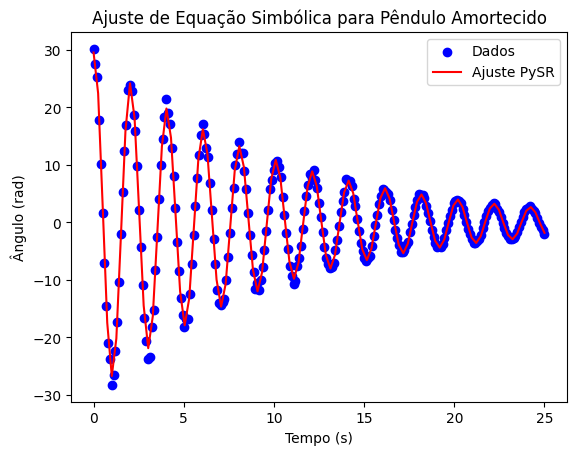

In [2]:
import numpy as np
from pysr import PySRRegressor
import matplotlib.pyplot as plt

data = np.loadtxt("../data/raw/dados_pendulo_amortecido.csv", delimiter=",", skiprows=1)
t = data[:, 0]
y = data[:, 1]

t = t.reshape(-1, 1)

model = PySRRegressor(
    model_selection="best", # Foca na precisão em vez de apenas simplicidade
    niterations=100,
    #operadores
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["square", "cos", "exp", "log", "sin"],
    temp_equation_file=True,
    delete_tempfiles=True,
    output_directory=None, # Tenta não criar a pasta 'outputs'

    # para o ruido, ainda falta melhorar
    # weights=1.0 / (np.full_like(y, 0.1)**2),
    #complexidade e parsimônia

    maxsize=30, # Limita o tamanho da equação para não "alucinar" no ruído
    #parsimony=0.001
)
model.fit(t, y)

print("\nEquação com relação de variáveis:")
print(model.get_best().equation)

#plotando os dados e a curva ajustada
t_fit = np.linspace(t.min(), t.max(), 100).reshape(-1, 1)
y_fit = model.predict(t_fit)
plt.scatter(t, y, label="Dados", color="blue")
plt.plot(t_fit, y_fit, label="Ajuste PySR", color="red")
plt.xlabel("Tempo (s)")
plt.ylabel("Ângulo (rad)")
plt.title("Ajuste de Equação Simbólica para Pêndulo Amortecido")
plt.legend()
plt.show()


## Problema 4 — Lei de Resfriamento de Newton

### Objetivo
Redescobrir a lei de decaimento térmico de um corpo em equilíbrio com o meio:

$$T(t) = T_{amb} + (T_0 - T_{amb})e^{-kt}$$

onde $T_{amb}$ é a temperatura de estabilização e $k$ a constante de resfriamento.

### Escolha dos operadores
O fenômeno é um decaimento exponencial puro, tornando o operador `exp` indispensável. Operadores básicos (`+`, `-`, `*`, `/`) são necessários para ajustar o deslocamento vertical (temperatura ambiente) e o fator de escala da amplitude. Operadores oscilatórios como `sin` e `cos` foram removidos para evitar que o modelo tente ajustar o ruído térmico como se fossem ciclos.

### Parâmetros do modelo
Utilizou-se `denoising=True` devido ao ruído de 5% inserido nos dados, que se torna mais crítico conforme a temperatura se aproxima da assíntota. O `maxsize` foi mantido em 20, o suficiente para capturar a estrutura "soma + produto + exponencial".

### Limitação: a ambiguidade das constantes
O modelo pode apresentar a solução de formas algebricamente diferentes, como `T = 25 + 75/exp(0.1*t)`. Além disso, se o tempo total de amostragem ($5\tau$) for pequeno, o modelo pode confundir o decaimento exponencial com uma função racional ($1/x$).

### Resultado esperado
Uma função que estabilize em um valor próximo a 25 no tempo infinito: `T = 25.1 + 74.8 * exp(-0.099 * t)`.

In [2]:
import pandas as pd
df = pd.read_csv("../data/raw/dados_resfriamento_newton.csv")
print(df.head(10))
print(df.describe())

#o erro está muito alto, por isso tava dando erro, ja foi corrigido

      tempo  temperatura
0  0.000000    99.966171
1  0.100200    98.504139
2  0.200401    98.464587
3  0.300601    97.870956
4  0.400802    97.414543
5  0.501002    95.612629
6  0.601202    95.343388
7  0.701403    94.755793
8  0.801603    94.492789
9  0.901804    93.806271
            tempo  temperatura
count  500.000000   500.000000
mean    25.000000    39.941985
std     14.477138    18.541170
min      0.000000    25.507195
25%     12.500000    26.762899
50%     25.000000    31.170946
75%     37.500000    46.600318
max     50.000000    99.966171


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


c:\projeto\symbolic_regression_physics\.venv\Lib\site-packages\pysr\sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
c:\projeto\symbolic_regression_physics\.venv\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 4.290e+05
Progress: 1215 / 15500 total iterations (7.839%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.555e+01  0.000e+00  y = 39.936
3           5.515e+01  1.574e-01  y = 64.936 - x₀
5           1.256e+01  7.398e-01  y = (x₀ * -0.54875) + 53.655
7           1.256e+01  -0.000e+00  y = ((x₀ * 0.45121) - -53.656) - x₀
9           1.882e+00  9.491e-01  y = 60.918 - (((81.42 - x₀) * x₀) * 0.017466)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 4.450e+05
Progress: 2462 / 15500 total iterations (15.884%)
═════

[ Info: Final population:
[ Info: Results saved to:


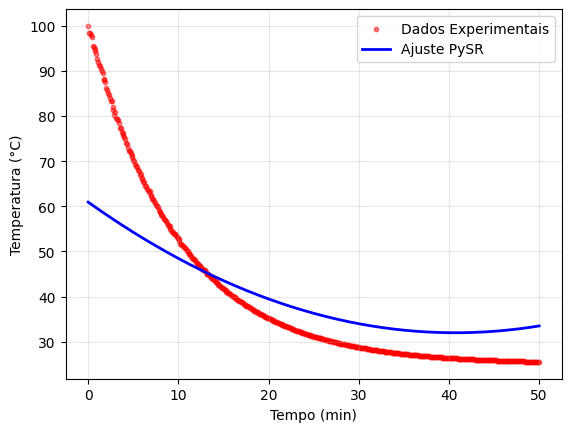

  - C:\\Users\\luizf\\AppData\\Local\\Temp\\tmpo3f6vgky\20260331_180600_6608DC\hall_of_fame.csv


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pysr import PySRRegressor

# Carregamento
data = np.loadtxt("../data/raw/dados_resfriamento_newton.csv", delimiter=",", skiprows=1)
t = data[:, 0].reshape(-1, 1)
T = data[:, 1]

model = PySRRegressor(
    niterations=500, 
    binary_operators=["+", "-", "*"],
    unary_operators=["exp"],
    maxsize=9, 
    constraints={"exp": 1}, 
    nested_constraints={"exp": {"exp": 0}}, 
    optimizer_iterations=60,
    optimizer_nrestarts=20,
    
    # Use o que a sua versão está pedindo:
    denoise=True, 
    
    model_selection="best", 
    variable_names=["t"],
    temp_equation_file=True,
    delete_tempfiles=True,
    output_directory=None
)

# Se o erro persistir mesmo após o downgrade do scikit-learn,
# tente passar os dados como float32, que às vezes pula validações complexas
model.fit(t.astype(np.float32), T.astype(np.float32))

print("\nEquação encontrada:")
print(model.get_best().equation)

# Plotagem
t_fit = np.linspace(t.min(), t.max(), 200).reshape(-1, 1)
T_fit = model.predict(t_fit)

plt.scatter(t, T, label="Dados Experimentais", color="red", alpha=0.5, s=10)
plt.plot(t_fit, T_fit, label="Ajuste PySR", color="blue", linewidth=2)
plt.xlabel("Tempo (min)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

c:\projeto\symbolic_regression_physics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 